In [140]:
import pandas as pd
import numpy as np
import seaborn as sns

import sys
sys.path.append('..')  # Adjust the path to point to the project root if necessary

from src.config import RAW_DATA_DIR

In [ ]:
import pandas as pd
import numpy as np

def feature_engineering(df):
    # 1. Title Extraction from Name
    df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
    df['Title'] = df['Title'].replace(['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr',
                                       'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
    df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

    # 2. Family Size
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

    # 3. Deck from Cabin
    df['Deck'] = df['Cabin'].astype(str).str[0]
    df['Deck'] = df['Deck'].fillna('U')

    # 4. Ticket Group Size
    ticket_counts = df['Ticket'].value_counts()
    df['TicketGroupSize'] = df['Ticket'].map(ticket_counts)

    # 5. Fare per Person
    df['FarePerPerson'] = df['Fare'] / df['FamilySize']
    df['FarePerPerson'].replace([np.inf, -np.inf], np.nan, inplace=True)

    # 6. Binning Age and Fare
    df['AgeBin'] = pd.cut(df['Age'], bins=[0, 12, 20, 40, 60, 80], labels=False, include_lowest=True)
    df['FareBin'] = pd.qcut(df['Fare'], 4, labels=False)

    # 7. Interaction Features
    df['Pclass*AgeBin'] = df['Pclass'] * df['AgeBin'].fillna(0).astype(int)

    # 8. Missing Value Indicators
    df['CabinMissing'] = df['Cabin'].isnull().astype(int)
    df['AgeMissing'] = df['Age'].isnull().astype(int)

    return df


In [142]:
df = pd.read_csv(RAW_DATA_DIR/"train.csv")
df_features = df.copy()
df_features = feature_engineering(df_features)

C:\Users\Fady Adel\AppData\Local\Temp\ipykernel_13732\2538643526.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['FarePerPerson'].replace([np.inf, -np.inf], np.nan, inplace=True)


In [143]:
# display all columns in the dataframe
pd.set_option('display.max_columns', None)
df_features.head(1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize,IsAlone,Deck,TicketGroupSize,FarePerPerson,AgeBin,FareBin,Pclass*AgeBin,Sex_Pclass,CabinMissing,AgeMissing
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S,Mr,2,0,n,1,3.625,2.0,0,6,male_3,1,0


In [144]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [145]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [146]:
# print unique values in the all columns except columns in skip_cols
skip_cols = ['PassengerId', 'Name','Age','Ticket','Fare','Cabin']
for col in df.columns:
    if col in skip_cols:
        continue
    print(f"Unique values in {col}: {df[col].unique()}")

Unique values in Survived: [0 1]
Unique values in Pclass: [3 1 2]
Unique values in Sex: ['male' 'female']
Unique values in SibSp: [1 0 3 4 2 5 8]
Unique values in Parch: [0 1 2 5 3 4 6]
Unique values in Embarked: ['S' 'C' 'Q' nan]


<Axes: >

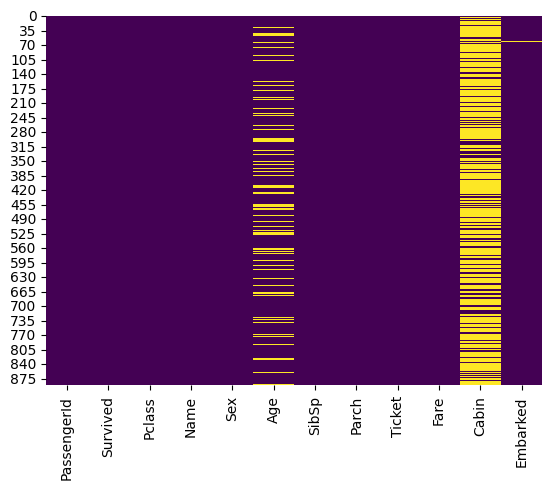

In [147]:
# visualize the missing values in the dataset
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')

<Axes: >

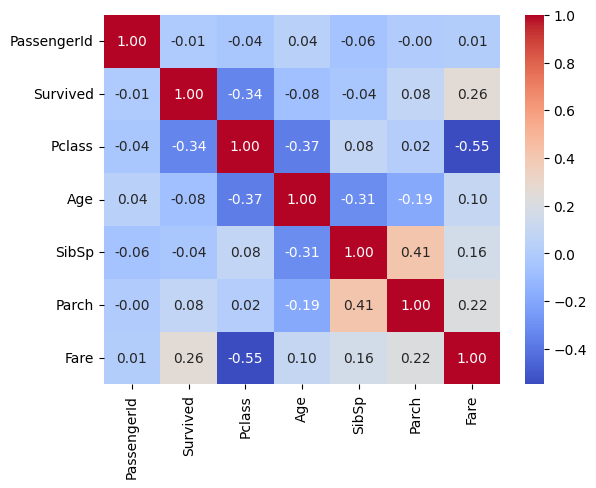

In [148]:
# Select only numeric columns for correlation computation
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')

# single column visualization

<Axes: xlabel='Survived', ylabel='count'>

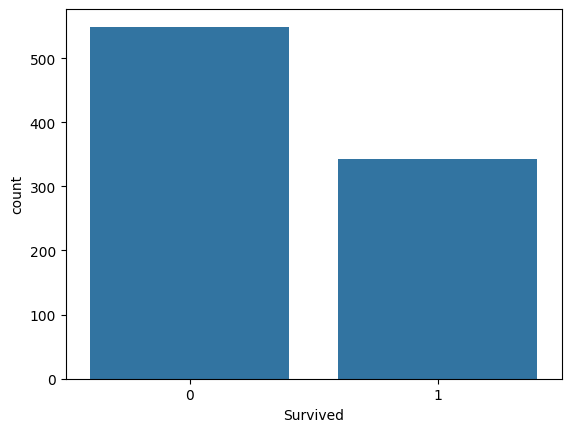

In [149]:
# visualize the servived column
sns.countplot(x='Survived', data=df)

<Axes: xlabel='Pclass', ylabel='count'>

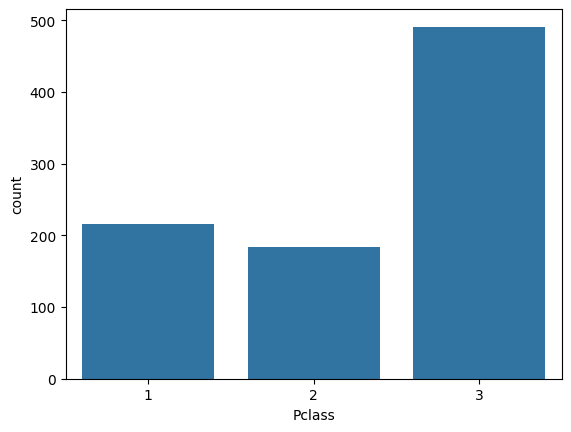

In [150]:
# visualize the Pclass column
sns.countplot(x='Pclass', data=df)

<Axes: xlabel='Sex', ylabel='count'>

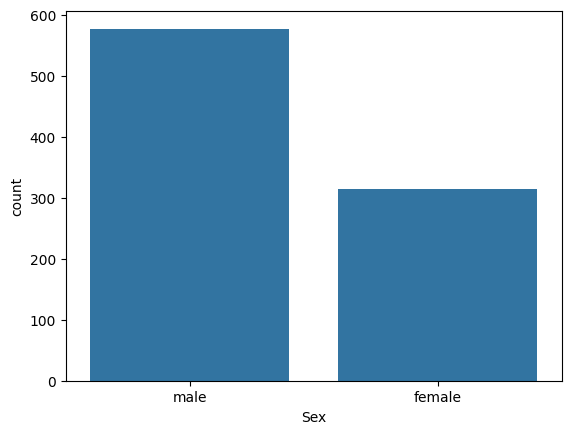

In [151]:
# visualize the Sex column
sns.countplot(x='Sex', data=df)

<Axes: xlabel='SibSp', ylabel='count'>

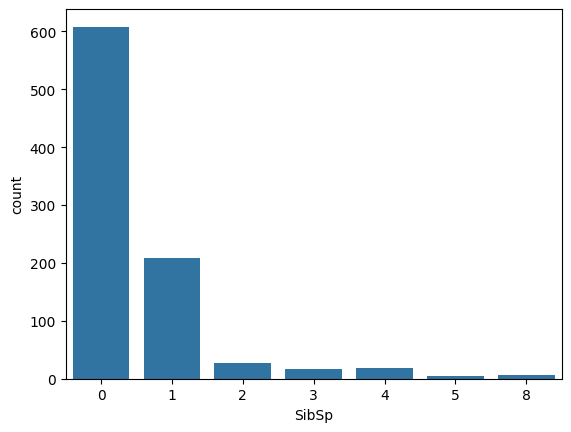

In [152]:
sns.countplot(x="SibSp", data=df)

<Axes: xlabel='Parch', ylabel='count'>

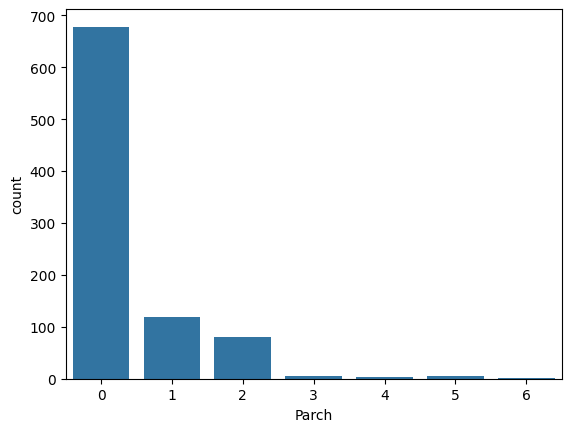

In [153]:
sns.countplot(x="Parch",data=df)

<Axes: xlabel='Embarked', ylabel='count'>

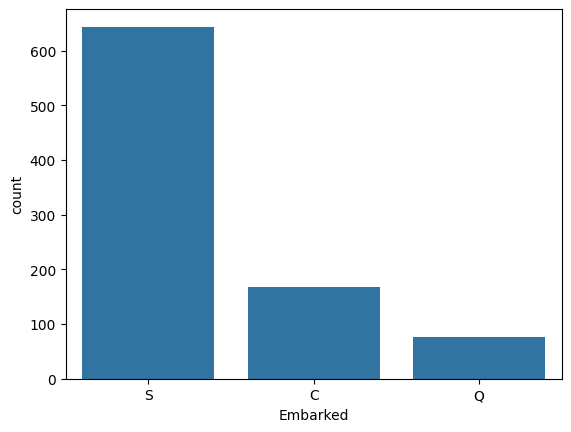

In [154]:
sns.countplot(x="Embarked",data=df)

<Axes: xlabel='Age', ylabel='Count'>

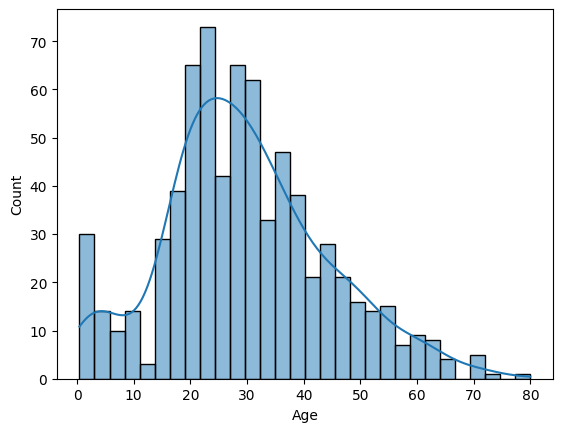

In [155]:
# plot the age distribution
sns.histplot(df['Age'].dropna(), bins=30, kde=True)

<Axes: xlabel='Fare', ylabel='Count'>

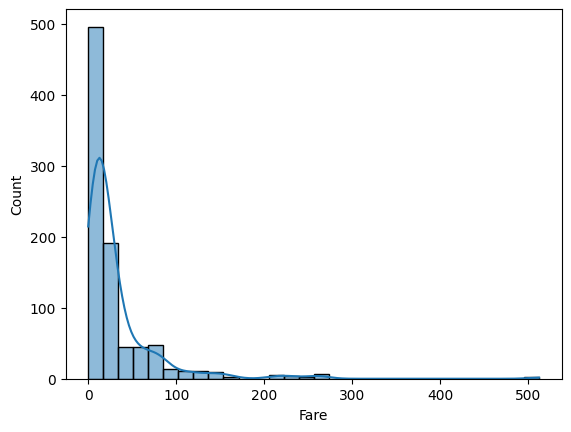

In [156]:
# plot the fare distribution
sns.histplot(df['Fare'].dropna(), bins=30, kde=True)

# multivariate analysis

<Axes: xlabel='Survived', ylabel='count'>

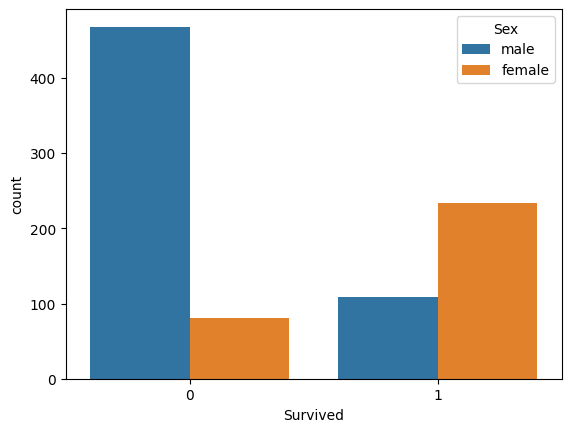

In [157]:
sns.countplot(x='Survived',data=df,hue='Sex')


<Axes: xlabel='Survived', ylabel='count'>

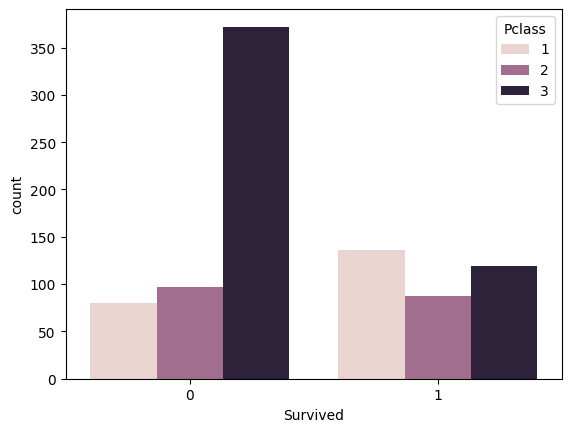

In [158]:
sns.countplot(x='Survived', data=df, hue='Pclass')

<Axes: xlabel='Age', ylabel='Count'>

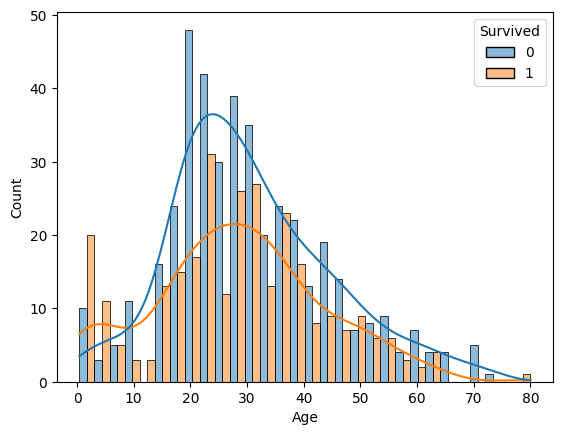

In [159]:
sns.histplot(data=df, x='Age', hue='Survived', multiple='dodge', bins=30, kde=True)

<Axes: xlabel='Survived', ylabel='Fare'>

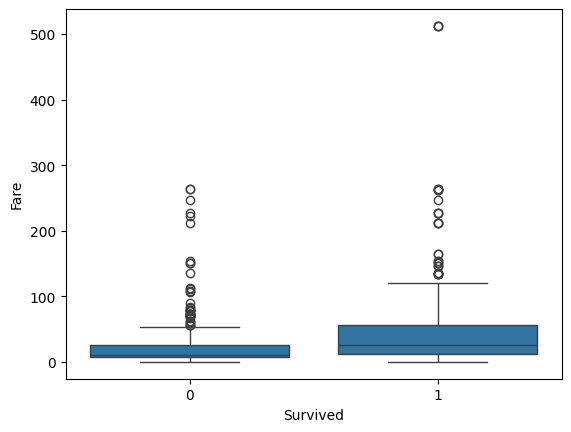

In [160]:
sns.boxplot(x='Survived', y='Fare', data=df)

<Axes: xlabel='Embarked', ylabel='count'>

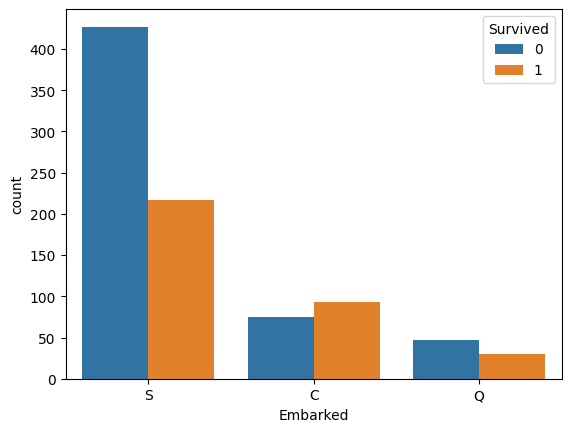

In [161]:
sns.countplot(x='Embarked', hue='Survived', data=df)

<Axes: xlabel='FamilySize', ylabel='count'>

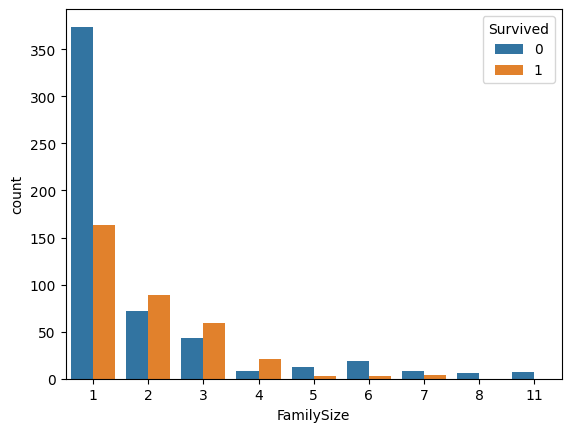

In [162]:
sns.countplot(x='FamilySize', hue='Survived', data=df_features)